# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [45]:
#The objective is to identify the key factors that influence the price of used cars and understand what drives their valuation and saleability in the market.

In [46]:
# It’s a Supervised learning problem (regression based task) where the goal is to model the relationship between vehicle attributes and price.

In [47]:
#Given a dataset of used cars with features such as vehicle age , mileage (odometer reading) , manufacturer and vehicle type, condition and fuel type , transmission and drive 

In [48]:
# I aim to learn a predictive function f(X) --> y 
# where X = vector of input features (car attributes) 
# y = continuous target variable (price)

In [49]:
#Analytical Objectives
# 1. Prediction Objective: Estimate the price of a used car based on its features. 
# 2. Inference Objective: Quantify the marginal impact of each feature on price to identify: 
# positive drivers (increase price) 
# negative drivers (decrease price) 
# 3. Decision Support Objective
# Translate model outputs into:
#inventory selection strategy 
#pricing recommendations


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [52]:
import pandas as pd
import numpy as np
df = pd.read_csv("data/vehicles.csv")  # Load the vehicles dataset into a DataFrame
print("Shape:", df.shape)# Display the number of rows and columns in the dataset
df.tail()  # View the last five records of the dataset
#df.head()  # View the first five records of the dataset

Shape: (426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy
426879,7301591129,wyoming,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,clean,other,WBA4J1C58KBM14708,rwd,NaN,coupe,NaN,wy


In [54]:
df.nunique().sort_values(ascending=False) # used with an aim to remove the column if size is same as dataset

id              426880
VIN             118246
odometer        104870
model            29649
price            15655
region             404
year               114
state               51
manufacturer        42
type                13
paint_color         12
cylinders            8
condition            6
title_status         6
fuel                 5
size                 4
transmission         3
drive                3
dtype: int64

In [55]:
df.isnull().mean().sort_values(ascending=False) # selecting which columns to be dropped 

size            0.717675
cylinders       0.416225
condition       0.407852
VIN             0.377254
drive           0.305863
paint_color     0.305011
type            0.217527
manufacturer    0.041337
title_status    0.019308
model           0.012362
odometer        0.010307
fuel            0.007058
transmission    0.005988
year            0.002823
id              0.000000
region          0.000000
price           0.000000
state           0.000000
dtype: float64

In [56]:
useless_cols = ["id", "VIN"]  # Define columns that are not useful for analysis
df_clean = df.drop(columns=useless_cols, errors="ignore") # Remove unnecessary columns from the dataset
df_clean.info() # Display dataset structure and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        426880 non-null  object 
 1   price         426880 non-null  int64  
 2   year          425675 non-null  float64
 3   manufacturer  409234 non-null  object 
 4   model         421603 non-null  object 
 5   condition     252776 non-null  object 
 6   cylinders     249202 non-null  object 
 7   fuel          423867 non-null  object 
 8   odometer      422480 non-null  float64
 9   title_status  418638 non-null  object 
 10  transmission  424324 non-null  object 
 11  drive         296313 non-null  object 
 12  size          120519 non-null  object 
 13  type          334022 non-null  object 
 14  paint_color   296677 non-null  object 
 15  state         426880 non-null  object 
dtypes: float64(2), int64(1), object(13)
memory usage: 52.1+ MB


In [57]:
df_clean.columns # Display column names after removing unnecessary columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'size', 'type', 'paint_color', 'state'],
      dtype='object')

In [6]:
df_clean.shape  # Display the dimensions of the cleaned dataset df_clean

(426880, 16)

In [60]:
(df_clean.isnull().mean() * 100).sort_values(ascending=False) # Calculating and displaying % of missing values per column


cylinders       41.476561
condition       40.464086
drive           30.580476
paint_color     30.400338
type            21.783151
manufacturer     3.860741
title_status     1.746317
model            1.232959
fuel             0.515493
transmission     0.402284
region           0.000000
price            0.000000
year             0.000000
odometer         0.000000
state            0.000000
dtype: float64

In [65]:
df_clean = df_clean.drop(columns=["size"], errors = "ignore") # Remove column with high percentage of missing values
df_clean = df_clean.dropna(subset=["price", "year", "odometer"]) # Remove rows missing critical features required for analysis

# Assistant
This error occurs because the code is trying to drop a column named "size" that doesn't exist in the DataFrame `df_clean`. The column either:
1. Doesn't exist in the original DataFrame
2. Has already been dropped in a previous operation
3. Has a different name (possibly with different capitalization or spacing)

To fix this error, you should check if the column exists before trying to drop it, or use the `errors='ignore'` parameter to avoid the error if the column doesn't exist.

Would you like me to provide the corrected code?

# Assistant
This error occurs because the code is trying to drop a column named "size" that doesn't exist in the DataFrame `df_clean`. The column either:
1. Doesn't exist in the original DataFrame
2. Has already been dropped in a previous operation
3. Has a different name (possibly with different capitalization or spacing)

To fix this error, you should check if the column exists before trying to drop it, or use the `errors='ignore'` parameter to avoid the error if the column doesn't exist.

Would you like me to provide the corrected code?

In [66]:
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median()) # imputing the remaining numerical values
    

In [67]:
cat_cols = df_clean.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna("Unknown") # imputing the remaining categorical values

print("Remaining NaNs:", df_clean.isnull().sum().sum())

Remaining NaNs: 0


In [68]:
current_year = 2026 # selecting current year to find the car age
df_clean["car_age"] = current_year - df_clean["year"] # because buyers think in terms of age, not year and has strong negative relationship with price
df_clean["mileage_per_year"] = df_clean["odometer"] / df_clean["car_age"].replace(0, 1)
df_clean = df_clean.drop(columns=["year"]) # because car_age has already captured the relevant information more meaningfully

# Now removing extreme prices as well as mileage
df_clean = df_clean[
    (df_clean["price"] > 500) & 
    (df_clean["price"] < 100000)
]
df_clean = df_clean[df_clean["odometer"] < 300000]
df_clean["log_price"] = np.log1p(df_clean["price"])
df_clean.head()


,region,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,car_age,mileage_per_year,log_price
27,auburn,33590,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,Unknown,pickup,white,al,12.0,4826.916667,10.422013
28,auburn,22590,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,Unknown,pickup,blue,al,16.0,4451.812500,10.025307
29,auburn,39590,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,Unknown,pickup,red,al,6.0,3193.333333,10.586357
30,auburn,30990,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,Unknown,pickup,red,al,9.0,4569.333333,10.341452
31,auburn,15000,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,13.0,9846.153846,9.615872


In [70]:
df_clean.describe() # Generate summary statistics for numerical columns in the dataset

,price,odometer,car_age,mileage_per_year,log_price
count,376956.000000,376956.000000,376956.000000,376956.000000,376956.000000
mean,19180.195678,91898.156193,14.949655,6346.612250,9.540567
std,14291.768866,61748.359273,9.499943,3662.940311,0.882327
min,501.000000,0.000000,4.000000,0.000000,6.218600
25%,7900.000000,38256.000000,9.000000,3557.545455,8.974745
50%,15962.000000,87200.000000,13.000000,6232.916667,9.678029
75%,27990.000000,135000.000000,18.000000,8709.679117,10.239638
max,99999.000000,299999.000000,126.000000,51958.500000,11.512925


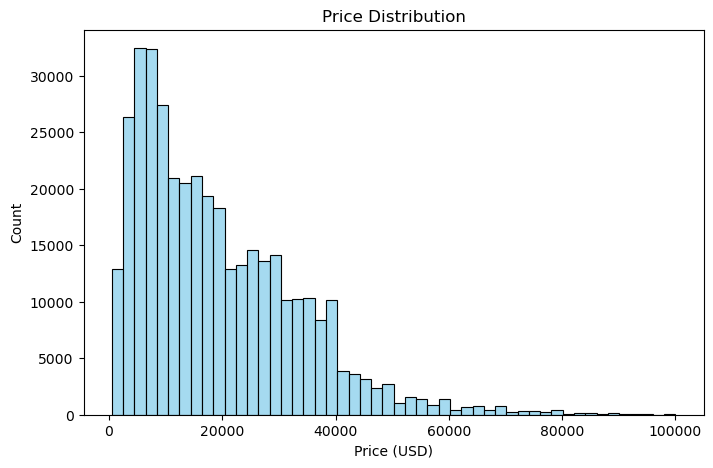

In [13]:
import seaborn as sns # Import seaborn for statistical visualization
import matplotlib.pyplot as plt  # Import matplotlib for plotting

plt.figure(figsize=(8,5)) # Create a figure with specified size

sns.histplot(df_clean["price"], bins=50, color="skyblue") # Plot histogram of car prices

plt.xlabel("Price (USD)") # Label x-axis as price
plt.title("Price Distribution") # Adding title to the plot
plt.show()     # Display the plot

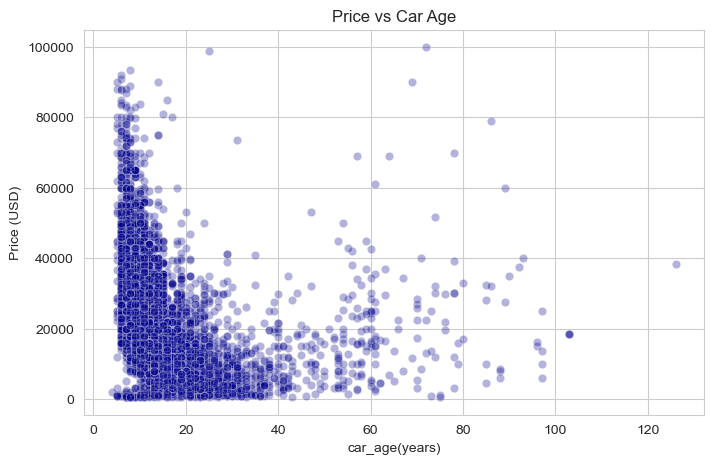

In [71]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="car_age",# Set car age as x-axis
    y="price", # Set price as y-axis
    data=df_clean.sample(10000),# Using a sample of the dataset for visualization
    alpha=0.3,# Adjusting transparency of points
    color="darkblue" # Setting color of the points
)

plt.title("Price vs Car Age")
plt.ylabel("Price (USD)")
plt.xlabel("car_age(years)")
plt.show()     

# Conclusion is "newer cars lead to higher prices"


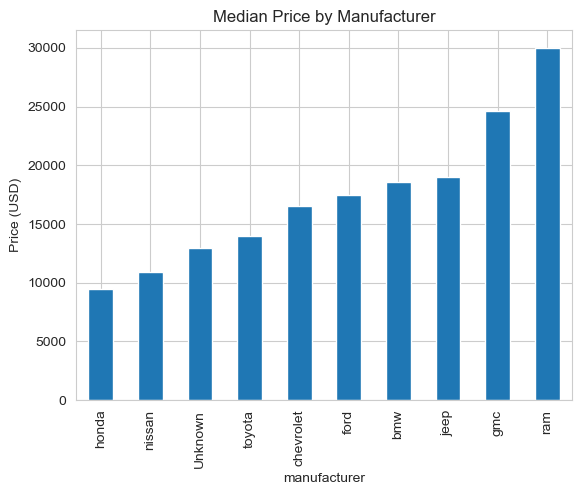

In [75]:
# Identify top 10 manufacturers by frequency
# Filter dataset for top manufacturers
# Compute median price for each manufacturer
# Sort manufacturers by median price
# Plot bar chart of median prices
top_brands = df_clean["manufacturer"].value_counts().nlargest(10).index 

df_clean[df_clean["manufacturer"].isin(top_brands)] \
.groupby("manufacturer")["price"].median() \
.sort_values() \
.plot(kind="bar") 

plt.title("Median Price by Manufacturer")
plt.ylabel("Price (USD)")
plt.show()    

#Conclusion : There is a significant impact of "Brand Value"

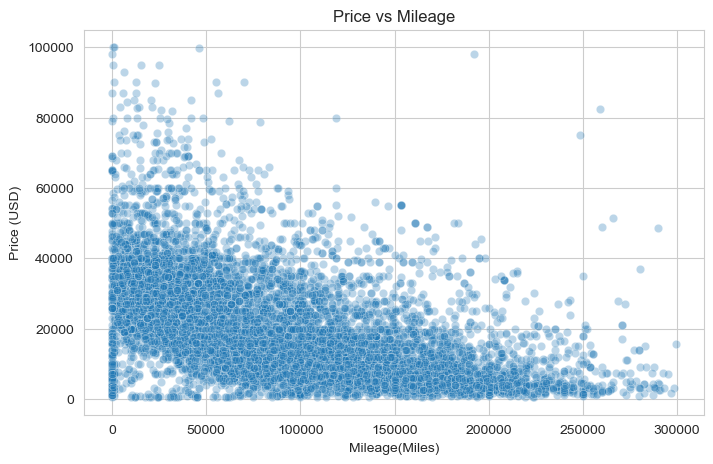

In [78]:
# Set odometer (mileage) as x-axis
# Set price as y-axis
# Use a sample of the dataset for visualization
# Adjusting transparency of points

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="odometer",
    y="price",
    data=df_clean.sample(10000),
    alpha=0.3
)

plt.title("Price vs Mileage")
plt.xlabel("Mileage(Miles)")
plt.ylabel("Price (USD)")
plt.show()   
# Conclusion is "Higher mileage leads to lower price"

/var/folders/p3/c7gw85cs7tg2rddmmwl7ncfw0000gn/T/ipykernel_29023/699280312.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Figure size 800x500 with 0 Axes>

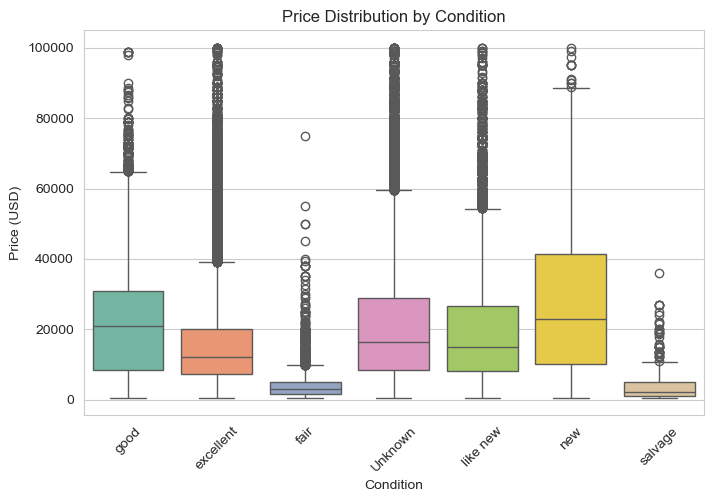

In [79]:
#visualizing how car prices vary across different condition categories

plt.figure(figsize=(8,5))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x="condition",
    y="price",
    data=df_clean,
    palette="Set2"  
)

plt.xticks(rotation=45)
plt.xlabel("Condition")            
plt.ylabel("Price (USD)")
plt.title("Price Distribution by Condition")

plt.show()    
# This plot shows how the price of cars differs depending on their condition
#Conclusion: Better Condition leads to Higher Price i.e. Cars in better condition tend to have higher median prices
# while poorer conditions show lower prices and greater variability

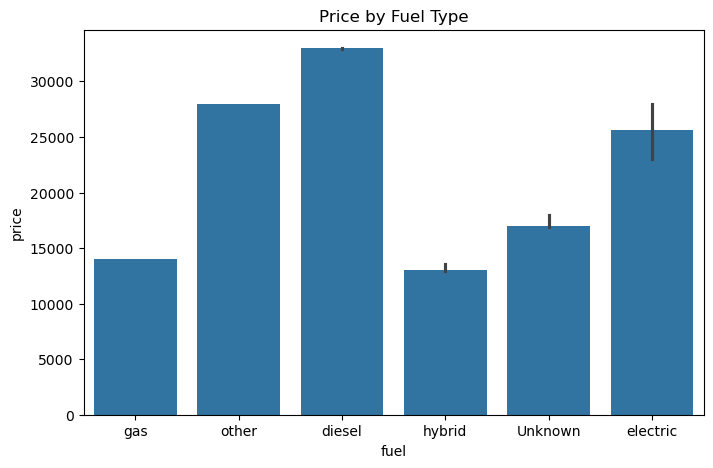

In [20]:
# comparing the median car prices across different fuel types
plt.figure(figsize=(8,5))

sns.barplot(
    x="fuel",
    y="price",
    data=df_clean,
    estimator="median"
)

plt.title("Price by Fuel Type")
plt.show() 
#Certain fuel categories (diesel or electric) may command higher market value depending on demand.

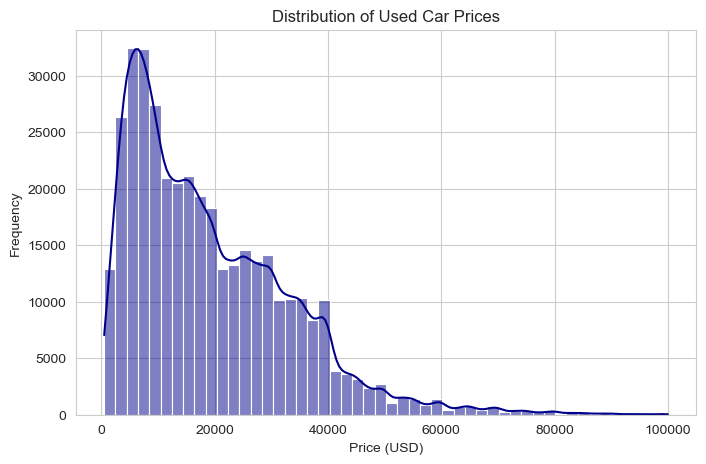

In [80]:
#visualizing the distribution and density of used car prices
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["price"],
    bins=50,
    color="darkblue",
    kde=True     
)

plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Used Car Prices")

plt.show()   
#The price distribution is right-skewed, indicating that most cars are lower-priced with a smaller number of high-priced outliers.

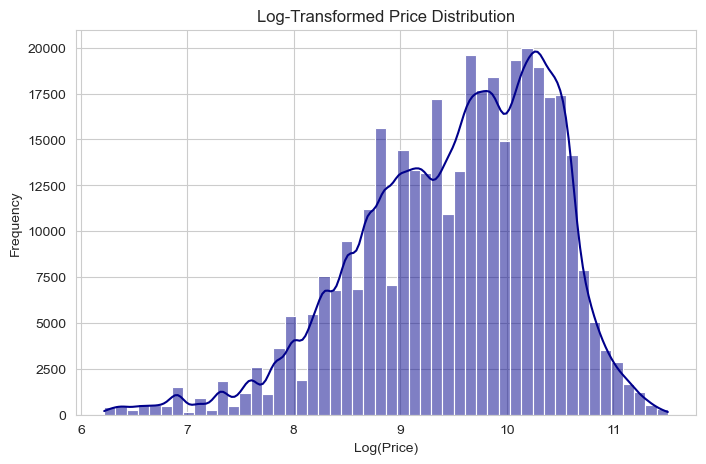

In [81]:
#visualizing the distribution of log-transformed car prices for improved interpretability.
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(df_clean["price"]),
    bins=50,
    color="darkblue",
    kde=True  
)

plt.xlabel("Log(Price)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Price Distribution")

plt.show()
#log transformation reduces skewness, resulting in a more symmetric distribution that is better suited for modeling.

<Axes: >

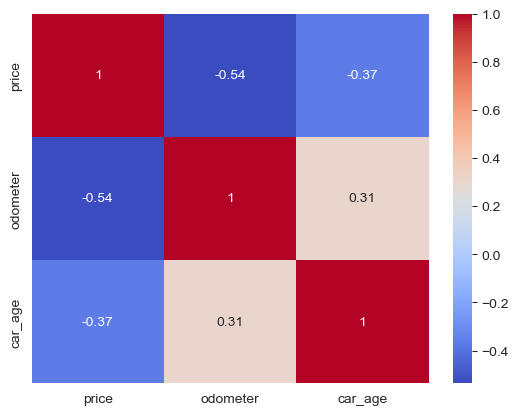

In [82]:
#visualizing the correlation between price, mileage, and car age
sns.set_style("whitegrid")
sns.heatmap(
    df_clean[["price", "odometer", "car_age"]].corr(),
    annot=True,
    cmap="coolwarm"
)
#Price shows negative correlation with both mileage and car age, indicating that older and more-used cars tend to have lower prices.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [24]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 376956 entries, 27 to 426879
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   region            376956 non-null  object 
 1   price             376956 non-null  int64  
 2   manufacturer      376956 non-null  object 
 3   model             376956 non-null  object 
 4   condition         376956 non-null  object 
 5   cylinders         376956 non-null  object 
 6   fuel              376956 non-null  object 
 7   odometer          376956 non-null  float64
 8   title_status      376956 non-null  object 
 9   transmission      376956 non-null  object 
 10  drive             376956 non-null  object 
 11  type              376956 non-null  object 
 12  paint_color       376956 non-null  object 
 13  state             376956 non-null  object 
 14  car_age           376956 non-null  float64
 15  mileage_per_year  376956 non-null  float64
 16  log_price         376956

In [83]:
# Condition encoding and Age group

df_clean["condition"] = df_clean["condition"].str.lower().fillna("unknown")

condition_map = {
    "new": 5,
    "like new": 4,
    "excellent": 3,
    "good": 2,
    "fair": 1,
    "salvage": 0,
    "unknown": 0
}

df_clean["condition_encoded"] = df_clean["condition"].map(condition_map).fillna(0)


df_clean["clean_title"] = (df_clean["title_status"] == "clean").astype(int) # Clean title


luxury_brands = ["bmw", "mercedes-benz", "audi", "lexus"] # Luxury
df_clean["is_luxury"] = df_clean["manufacturer"].str.lower().isin(luxury_brands).astype(int)


df_clean["age_group"] = pd.cut(
    df_clean["car_age"],
    bins=[0, 5, 10, 15, 30, 100],
    labels=["0-5", "5-10", "10-15", "15-30", "30+"]
) 


In [84]:

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 376956 entries, 27 to 426879
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   region             376956 non-null  object  
 1   price              376956 non-null  int64   
 2   manufacturer       376956 non-null  object  
 3   model              376956 non-null  object  
 4   condition          376956 non-null  object  
 5   cylinders          376956 non-null  object  
 6   fuel               376956 non-null  object  
 7   odometer           376956 non-null  float64 
 8   title_status       376956 non-null  object  
 9   transmission       376956 non-null  object  
 10  drive              376956 non-null  object  
 11  type               376956 non-null  object  
 12  paint_color        376956 non-null  object  
 13  state              376956 non-null  object  
 14  car_age            376956 non-null  float64 
 15  mileage_per_year   376956 non-null  fl

In [85]:
# Using smaller samples for faster execution
df_model = df_clean.sample(50000, random_state=42)

X = df_model.drop(columns=["price", "log_price"])
y = df_model["log_price"]

In [86]:
#Training and Testing split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [87]:
#Pipeline pre-processing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

# Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [88]:
#Developing Linear Regression Model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression Results:
MAE: 0.28471981513259836
RMSE: 0.49386664686452647
R2: 0.6914265554957905


In [35]:
#Random Forest Model
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=30,
        max_depth=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))


Random Forest Results:
MAE: 0.5696500216511667
RMSE: 0.7344029534381463
R2: 0.3176487625529453


In [89]:
#evaluating the performance of the Linear Regression model using 5-fold cross-validation
from sklearn.model_selection import cross_val_score

cv_scores_lr = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Linear Regression CV R2 Scores:", cv_scores_lr)
print("Mean Linear Regression CV R2:", cv_scores_lr.mean())
# model shows consistent R2 scores across folds, indicating stable and reliable predictive performance

Linear Regression CV R2 Scores: [0.69124296 0.70268498 0.69044674 0.6851941  0.70257454]
Mean Linear Regression CV R2: 0.6944286660237698


In [90]:
# Tuning Random Forest hyperparameters using grid search with cross-validation.
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [30, 50],
    "model__max_depth": [10, 15],
    "model__max_features": ["sqrt"]
}

grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R2 Score:", grid_search.best_score_)
# selected parameter combination provides the best cross-validated R2 score among the tested configurations.

Best Parameters: {'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__n_estimators': 30}
Best CV R2 Score: 0.4501799048791364


In [92]:
#extracting and organizing the Linear Regression coefficients for all features
coef = lr_model.named_steps["model"].coef_
feature_names = lr_model.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
}).sort_values(by="coefficient", ascending=False)

coef_df.head(10)
#Features with higher positive coefficients increase predicted price, while those with negative coefficients decrease it

,feature,coefficient
5362,cat__model_lx 450,3.673498
1474,cat__model_Freightliner Van,2.831256
5847,cat__model_oldsmobile 442,2.609469
1550,cat__model_International 5600I,2.506633
1608,cat__model_Mack Mack Granite Plow/Dump Truck W...,2.412330
1458,cat__model_Freightliner BUSINESS CLASS M2,2.333574
3038,cat__model_coupe de ville 62,2.322694
1398,"cat__model_Chevy,Ford, International",2.260574
5761,cat__model_navigator bl,2.259039
2237,cat__model_benz 190sl,2.255905


In [39]:
coef_df.tail(10) #display the 10 features with the lowest (most negative) coefficients from the Linear Regression model.
#These features contribute to decreasing the predicted car price in the model

,feature,coefficient
7960,cat__model_velar p2,-4.199447
6326,cat__model_ranger lariat supercrew 5,-4.202293
2699,cat__model_charger scat pack srt,-4.220880
573,cat__model_1500 rebel hemi loaded 4x4,-4.244837
551,cat__model_1500 lone star,-4.275004
867,cat__model_2500 tradesman usa truck,-4.283863
6928,cat__model_sierra 3500 sle,-4.395894
2504,cat__model_california t,-4.455497
555,cat__model_1500 maxed out big horn,-4.492206
5650,cat__model_model s 75,-4.792108


In [40]:
feature_importance_df.head(10) #displaying the top 10 most important features based on the model’s feature importance scores
#These features have significant influence on predicting car prices according to the model

,feature,importance
1,num__car_age,0.099979
8517,cat__age_group_15-30,0.087091
2,num__mileage_per_year,0.067455
8435,cat__drive_fwd,0.063730
8519,cat__age_group_5-10,0.059193
0,num__odometer,0.057100
8432,cat__transmission_other,0.047883
8417,cat__fuel_diesel,0.038092
8401,cat__condition_fair,0.031720
8410,cat__cylinders_4 cylinders,0.027596


In [41]:
#extracting, organizing, and ranking feature importance scores from the Random Forest model.
import pandas as pd

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(10)
#top features identified have the strongest impact on predicting car prices according to the model.

,feature,importance
1,num__car_age,0.099979
8517,cat__age_group_15-30,0.087091
2,num__mileage_per_year,0.067455
8435,cat__drive_fwd,0.063730
8519,cat__age_group_5-10,0.059193
0,num__odometer,0.057100
8432,cat__transmission_other,0.047883
8417,cat__fuel_diesel,0.038092
8401,cat__condition_fair,0.031720
8410,cat__cylinders_4 cylinders,0.027596


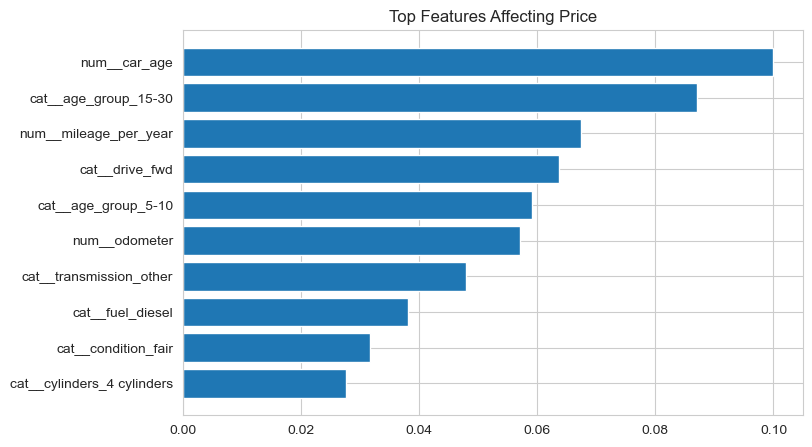

In [42]:
#visualizing the top 10 most important features influencing car price using a horizontal bar chart
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top Features Affecting Price")
plt.show()    
# Features with longer bars have greater influence on price prediction, indicating the most significant drivers of car value

In [ ]:
#The model clearly indicates that vehicle age and how much the car has been driven each year are the most important drivers
#while features like brand or fuel type play a smaller role.
#Relative contribution of each feature to the model’s prediction
#0.10 indicates very strong influence
#0.06 indicates moderate influence
#0.02 indicates smaller influence
# sum of all feature importances = 1.0

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

/var/folders/p3/c7gw85cs7tg2rddmmwl7ncfw0000gn/T/ipykernel_29023/3689020074.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


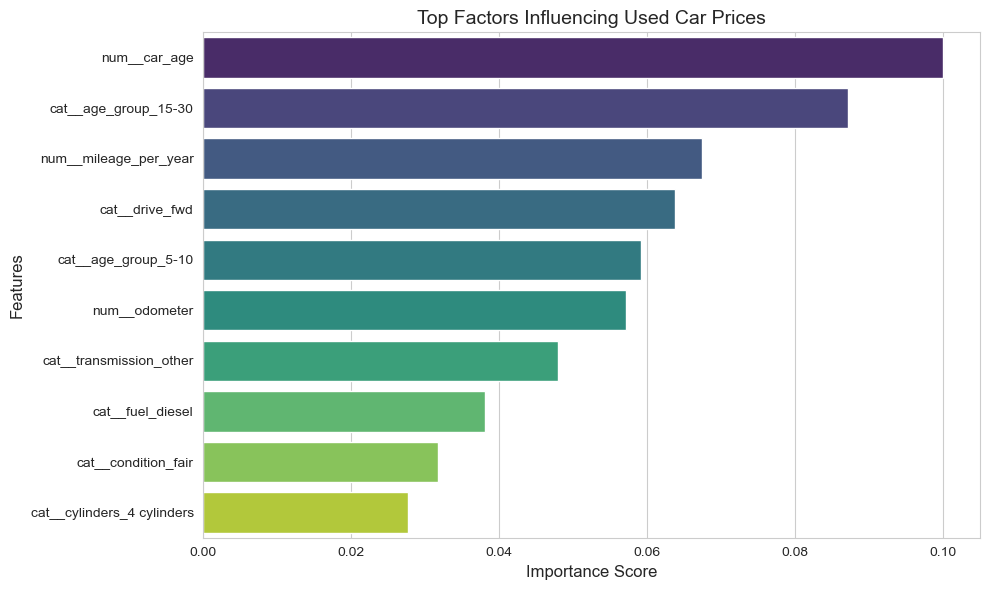

In [93]:
#displaying the top 10 features ranked by their importance scores using a Seaborn bar plot.
import seaborn as sns
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="importance",
    y="feature",
    data=top_features,
    palette="viridis"
)

plt.title("Top Factors Influencing Used Car Prices", fontsize=14)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()   
#plot highlights that a few key features dominate the model’s predictions, 
#indicating the most influential factors affecting used car prices.

In [ ]:
#This plot shows which factors most influence the price of used cars.


In [ ]:
#The model clearly indicates that vehicle age and how much the car has been driven each year are the most important drivers, while features like brand or fuel type play a smaller role.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

/var/folders/p3/c7gw85cs7tg2rddmmwl7ncfw0000gn/T/ipykernel_29023/2346971722.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


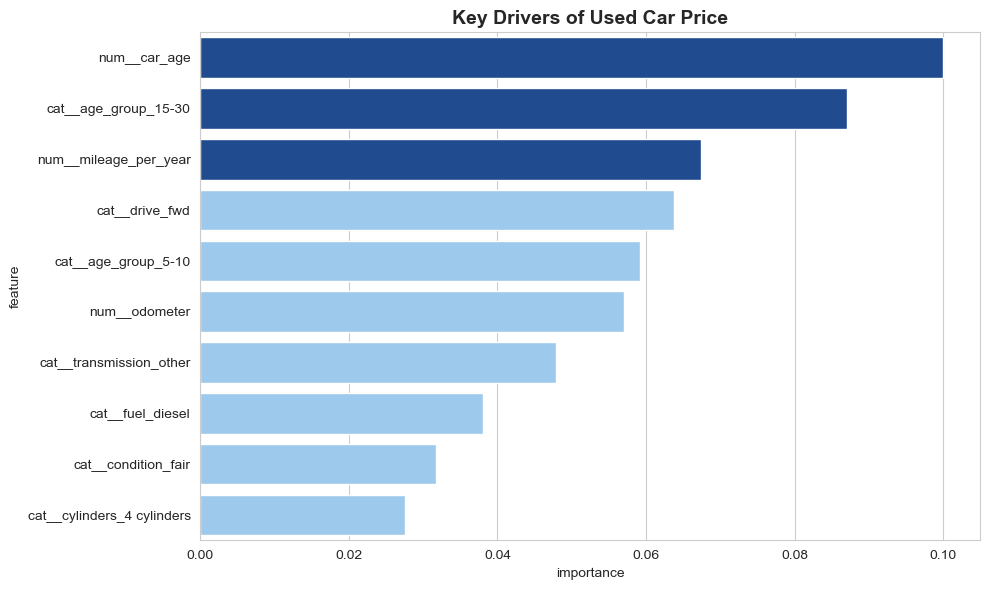

In [44]:
top_features = feature_importance_df.head(10)

colors = ["#0d47a1" if i < 3 else "#90caf9" for i in range(len(top_features))]

plt.figure(figsize=(10,6))

sns.barplot(
    x="importance",
    y="feature",
    data=top_features,
    palette=colors
)

plt.title("Key Drivers of Used Car Price", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()    # Display the plot

In [ ]:
#The plot highlights top 3 features 
#The darker bars represent the most influential factors, primarily vehicle age and usage patterns.
